# PyTorch Geometric Tutorial

This notebook is a practical introduction to **PyTorch Geometric (PyG)**, the graph-learning library we will use before beginning the mathematical material on Graph Neural Networks.

The goal is **not** to develop GNN theory yet. Instead, we will become comfortable with PyG's data model and APIs:

- `Data` and `edge_index`;
- node and edge features;
- masks;
- batching with `Batch` and `DataLoader`;
- datasets and transforms;
- the `MessagePassing` abstraction;
- standard layers such as `GCNConv`;
- node-level and graph-level readouts;
- the correspondence between PyG and the GDL blueprint from the previous notebook.

The guiding principle is: **construct small graphs by hand before using high-level datasets and layers.**

## 1. Why PyTorch Geometric?

For a graph

$$
G=(V,E),
$$

we may have a feature vector $x_i$ attached to each node, a feature vector $e_{ij}$ attached to each edge, and labels attached to nodes, edges, or the whole graph.

PyTorch provides tensors and automatic differentiation. PyG adds data structures and operations adapted to sparse graph-structured data.

A central design choice is that PyG represents graph connectivity explicitly rather than requiring a dense adjacency matrix.

## 2. Imports and versions

The basic PyG API works directly with PyTorch. Optional acceleration packages exist, but they are not needed for the material in this notebook.

In [1]:
import torch
import networkx as nx
import matplotlib.pyplot as plt

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, GCNConv, global_mean_pool

print("PyTorch:", torch.__version__)
print("PyG:", torch_geometric.__version__)

/opt/anaconda3/envs/gdl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/gdl/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


PyTorch: 2.14.0
PyG: 2.9.0.dev20260922


## 3. The central PyG object: `Data`

For a homogeneous graph, the most important PyG object is `torch_geometric.data.Data`.

If there are $N$ nodes and each node has $F$ features,

$$
x\in\mathbb R^{N \times F}.
$$

For $E$ directed edge entries,

$$
\texttt{edge\_index}\in\mathbb N^{2	\times E}.
$$

Each column records a source-target pair. This explicit sparse representation is the basic interface through which message passing accesses neighborhoods.

### A tiny graph

Consider the path

$$
0\longleftrightarrow1\longleftrightarrow2.
$$

For standard message passing on an undirected graph, we store both directions.

In [2]:
# One scalar feature per node.
x = torch.tensor([
    [1.0],
    [2.0],
    [3.0],
])

# Undirected edges 0--1 and 1--2,
# represented by both directed message-passing directions.
edge_index = torch.tensor([
    [0, 1, 1, 2],
    [1, 0, 2, 1],
], dtype=torch.long)

data = Data(x=x, edge_index=edge_index)

print(data)
print("x shape:", data.x.shape)
print("edge_index shape:", data.edge_index.shape)
print("num_nodes:", data.num_nodes)
print("num_edges:", data.num_edges)
print("num_node_features:", data.num_node_features)

Data(x=[3, 1], edge_index=[2, 4])
x shape: torch.Size([3, 1])
edge_index shape: torch.Size([2, 4])
num_nodes: 3
num_edges: 4
num_node_features: 1


## 4. `edge_index` in detail

For

```text
[[0, 1, 1, 2],
 [1, 0, 2, 1]]
```

the columns are

$$
(0,1),\quad(1,0),\quad(1,2),\quad(2,1).
$$

Thus the directed message-passing edges are

$$
0\to1,\quad1\to0,\quad1\to2,\quad2\to1.
$$

A useful mental model is:

> `edge_index` is an explicit list of which pairs of nodes are allowed to communicate.

## 5. NetworkX and PyG

NetworkX is particularly convenient for graph construction, algorithms, visualization, and graph-theoretic experiments.

PyG is particularly convenient for tensor-based graph learning, automatic differentiation, message passing, batching, and hardware acceleration.

There is no reason to choose only one: NetworkX is useful for inspecting graph structure, while PyG is useful for learning on that structure.

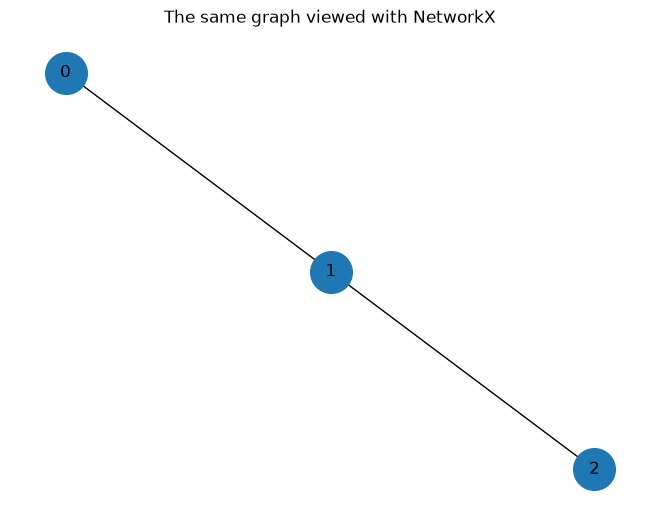

In [3]:
G = nx.Graph()
G.add_edges_from([(0, 1), (1, 2)])

pos = nx.spring_layout(G, seed=7)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=900,
    font_size=12,
)
plt.title("The same graph viewed with NetworkX")
plt.show()

## 6. Node features, edge features, and labels

A node-feature matrix may have any feature dimension:

$$
x\in\mathbb R^{N\times F}.
$$

If every edge has a feature in $\mathbb R^D$,

$$
e\in\mathbb R^{E\times D}.
$$

Labels can occur at different levels:

- node classification: one label per node;
- edge prediction/classification: one target per edge;
- graph classification/regression: one target per graph.

The `Data` object is deliberately flexible.

In [4]:
x = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])

edge_index = torch.tensor([
    [0, 1, 1, 2],
    [1, 0, 2, 1],
], dtype=torch.long)

# One scalar feature for every directed edge entry.
edge_attr = torch.tensor([
    [1.0],
    [1.0],
    [2.0],
    [2.0],
])

# One class label per node.
y = torch.tensor([0, 1, 0])

data = Data(
    x=x,
    edge_index=edge_index,
    edge_attr=edge_attr,
    y=y,
)

print(data)
print("Node feature shape:", data.x.shape)
print("Edge feature shape:", data.edge_attr.shape)
print("Node labels:", data.y)

Data(x=[3, 2], edge_index=[2, 4], edge_attr=[4, 1], y=[3])
Node feature shape: torch.Size([3, 2])
Edge feature shape: torch.Size([4, 1])
Node labels: tensor([0, 1, 0])


## 7. Masks

Many graph datasets use one large graph with different subsets of nodes assigned to training, validation, and test sets.

PyG commonly stores these subsets as boolean masks. For example,

$$
\texttt{train\_mask}[i]=\texttt{True}
$$

means that node $i$ belongs to the training set.

In [5]:
data.train_mask = torch.tensor([True, True, False])
data.val_mask = torch.tensor([False, False, True])
data.test_mask = torch.tensor([False, False, True])

print("Training nodes:", torch.where(data.train_mask)[0].tolist())
print("Validation nodes:", torch.where(data.val_mask)[0].tolist())
print("Test nodes:", torch.where(data.test_mask)[0].tolist())

Training nodes: [0, 1]
Validation nodes: [2]
Test nodes: [2]


## 8. Inspecting a `Data` object

A useful habit is to inspect graph data before writing a model.

PyG provides properties such as `num_nodes`, `num_edges`, `num_node_features`, and `num_edge_features`. The object can also contain additional attributes.

In [6]:
for key, value in data:
    if torch.is_tensor(value):
        print(f"{key:12s} shape={tuple(value.shape)} dtype={value.dtype}")
    else:
        print(f"{key:12s} value={value}")

x            shape=(3, 2) dtype=torch.float32
edge_index   shape=(2, 4) dtype=torch.int64
edge_attr    shape=(4, 1) dtype=torch.float32
y            shape=(3,) dtype=torch.int64
train_mask   shape=(3,) dtype=torch.bool
val_mask     shape=(3,) dtype=torch.bool
test_mask    shape=(3,) dtype=torch.bool


## 9. A slightly richer graph

Let's construct a four-cycle

$$
0-1-2-3-0.
$$

In [7]:
x = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [-1.0, 0.0],
    [0.0, -1.0],
])

edge_index = torch.tensor([
    [0, 1, 1, 2, 2, 3, 3, 0],
    [1, 0, 2, 1, 3, 2, 0, 3],
], dtype=torch.long)

cycle = Data(x=x, edge_index=edge_index)

print(cycle)
print("Nodes:", cycle.num_nodes)
print("Directed edge entries:", cycle.num_edges)

Data(x=[4, 2], edge_index=[2, 8])
Nodes: 4
Directed edge entries: 8


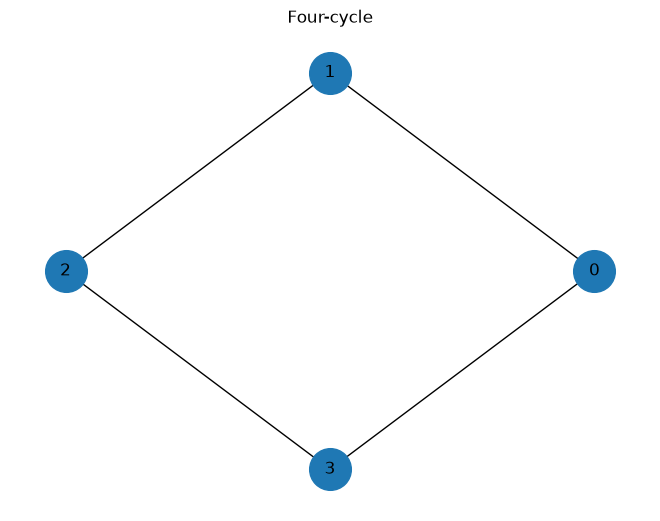

In [8]:
G = nx.cycle_graph(4)
pos = nx.circular_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=900,
    font_size=12,
)
plt.title("Four-cycle")
plt.show()

## 10. Batching several graphs

Suppose we have graphs $G_1,\ldots,G_B$. PyG can combine them into one `Batch` object.

Conceptually, the graphs remain separate, but their node and edge tensors are concatenated and the node indices in `edge_index` are shifted.

The corresponding adjacency structure is equivalent to a block-diagonal matrix

$$
A=
\begin{pmatrix}
A_1&0&\cdots&0\\
0&A_2&\cdots&0\\
\vdots&\vdots&\ddots&\vdots\\
0&0&\cdots&A_B
\end{pmatrix}.
$$

The `batch` vector records which graph each node belongs to.

In [9]:
graph1 = Data(
    x=torch.tensor([[1.0], [2.0]]),
    edge_index=torch.tensor([[0, 1], [1, 0]], dtype=torch.long),
)

graph2 = Data(
    x=torch.tensor([[3.0], [4.0], [5.0]]),
    edge_index=torch.tensor([
        [0, 1, 1, 2],
        [1, 0, 2, 1],
    ], dtype=torch.long),
)

loader = DataLoader([graph1, graph2], batch_size=2, shuffle=False)
batch = next(iter(loader))

print(batch)
print("Batched x:")
print(batch.x)
print("Batched edge_index:")
print(batch.edge_index)
print("batch vector:")
print(batch.batch)
print("Number of graphs:", batch.num_graphs)

DataBatch(x=[5, 1], edge_index=[2, 6], batch=[5], ptr=[3])
Batched x:
tensor([[1.],
        [2.],
        [3.],
        [4.],
        [5.]])
Batched edge_index:
tensor([[0, 1, 2, 3, 3, 4],
        [1, 0, 3, 2, 4, 3]])
batch vector:
tensor([0, 0, 1, 1, 1])
Number of graphs: 2


### Why does the `batch` vector matter?

If the concatenated node features are

$$
[x^{(1)}_1,x^{(1)}_2,x^{(2)}_1,x^{(2)}_2,x^{(2)}_3],
$$

the `batch` vector is

$$
[0,0,1,1,1].
$$

A graph-level pooling operation can therefore aggregate nodes from each graph separately.

## 11. A `DataLoader` over many graphs

In practice, we create a collection of `Data` objects and let the loader produce batches.

In [10]:
graphs = []

for n in [3, 4, 5, 6]:
    edges = []

    # Construct a path graph with n nodes.
    for i in range(n - 1):
        edges.append([i, i + 1])
        edges.append([i + 1, i])

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    x = torch.arange(n, dtype=torch.float32).view(-1, 1)

    graphs.append(Data(x=x, edge_index=edge_index))

loader = DataLoader(graphs, batch_size=2, shuffle=False)

for batch in loader:
    print(
        "graphs =", batch.num_graphs,
        "| nodes =", batch.num_nodes,
        "| edges =", batch.num_edges,
    )

graphs = 2 | nodes = 7 | edges = 10
graphs = 2 | nodes = 11 | edges = 18


## 12. Datasets

PyG provides standard graph datasets through `torch_geometric.datasets`.

A useful small example is the **Karate Club** graph. It is small enough to inspect directly.

The general workflow is

$$
\text{dataset}
\longrightarrow
\text{Data object(s)}
\longrightarrow
\text{model}.
$$

In [11]:
from torch_geometric.datasets import KarateClub

dataset = KarateClub()

print("Number of graphs:", len(dataset))
print("Number of classes:", dataset.num_classes)

karate = dataset[0]

print(karate)
print("Nodes:", karate.num_nodes)
print("Edges:", karate.num_edges)
print("Node features:", karate.num_node_features)

Number of graphs: 1
Number of classes: 4
Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
Nodes: 34
Edges: 156
Node features: 34


### Inspect the Karate Club graph

The dataset contains one graph. Its node labels are available through `y`, and the standard training mask is provided.

In [12]:
print("x shape:", karate.x.shape)
print("y shape:", karate.y.shape)
print("Training nodes:", int(karate.train_mask.sum()))
print("Classes:", torch.unique(karate.y).tolist())

x shape: torch.Size([34, 34])
y shape: torch.Size([34])
Training nodes: 4
Classes: [0, 1, 2, 3]


## 13. Transforms

A transform is a callable that receives a graph and returns a transformed graph.

Conceptually,

$$
T:\mathcal D\to\mathcal D.
$$

Transforms can normalize features, add structural information, convert representations, or otherwise prepare graphs for a model.

In [13]:
from torch_geometric.transforms import NormalizeFeatures

normalized = NormalizeFeatures()(karate)

print("Original feature row:", karate.x[0])
print("Normalized feature row:", normalized.x[0])

Original feature row: tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Normalized feature row: tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


## 14. The `MessagePassing` abstraction

Now we reach the most important PyG abstraction for the GNN material that follows.

PyG's `MessagePassing` class organizes a graph layer around:

1. **message** — construct a message from neighbors;
2. **aggregate** — combine messages arriving at a node;
3. **update** — construct the new node representation.

Schematically,

$$
x_i'
=
\gamma_\Theta
\left(
x_i,
\bigoplus_{j\in\mathcal N(i)}
\phi_\Theta(x_i,x_j,e_{j,i})
\right).
$$

Here $\phi_\Theta$ is the message function, $\bigoplus$ is a permutation-invariant aggregation operation, and $\gamma_\Theta$ is the update function.

## 15. A minimal custom message-passing layer

Consider the transparent operation

$$
x_i'=x_i+\sum_{j\in\mathcal N(i)}x_j.
$$

This is not intended as a useful learned model. It is a minimal example of the PyG API.

In [14]:
class NeighborSum(MessagePassing):
    def __init__(self):
        # Sum aggregation.
        super().__init__(aggr="add")

    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=x)

    def message(self, x_j):
        # Each neighbor sends its feature.
        return x_j

    def update(self, aggr_out, x):
        # Add the node's own feature.
        return x + aggr_out


layer = NeighborSum()

x = torch.tensor([
    [1.0],
    [2.0],
    [3.0],
])

edge_index = torch.tensor([
    [0, 1, 1, 2],
    [1, 0, 2, 1],
], dtype=torch.long)

out = layer(x, edge_index)

print("Input:")
print(x)
print("Output:")
print(out)

Input:
tensor([[1.],
        [2.],
        [3.]])
Output:
tensor([[3.],
        [6.],
        [5.]])


For the path $0-1-2$,

$$
x'_0=x_0+x_1,
$$

$$
x'_1=x_1+x_0+x_2,
$$

$$
x'_2=x_2+x_1.
$$

The layer never constructs a dense adjacency matrix. `edge_index` specifies where messages flow, and `MessagePassing` handles the neighborhood bookkeeping.

## 16. Aggregation is permutation invariant

The aggregation operation must not depend on an arbitrary ordering of a node's neighbors.

For example,

$$
x_1+x_2+x_3=x_3+x_1+x_2.
$$

Mean, minimum, maximum, and product are also permutation invariant.

PyG exposes these choices through the `aggr` argument.

In [15]:
class NeighborMean(MessagePassing):
    def __init__(self):
        super().__init__(aggr="mean")

    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=x)

    def message(self, x_j):
        return x_j


mean_layer = NeighborMean()
print(mean_layer(x, edge_index))

tensor([[2.],
        [2.],
        [2.]])


## 17. A learned message function

Let the message be

$$
m_{j\to i}=W x_j,
$$

followed by summation and a nonlinearity:

$$
x_i'
=
\sigma
\left(
\sum_{j\in\mathcal N(i)}W x_j
\right).
$$

This is close to a basic GNN layer, although we are deliberately postponing the mathematical development.

In [16]:
class LinearNeighborLayer(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr="add")
        self.linear = torch.nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=x)

    def message(self, x_j):
        return self.linear(x_j)

    def update(self, aggr_out):
        return torch.relu(aggr_out)


torch.manual_seed(7)

layer = LinearNeighborLayer(2, 3)

x = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])

out = layer(x, edge_index)

print("Output shape:", out.shape)
print(out)

Output shape: torch.Size([3, 3])
tensor([[0.0000, 0.4054, 0.0000],
        [0.0000, 1.0391, 0.0000],
        [0.0000, 0.4054, 0.0000]], grad_fn=<ReluBackward0>)


## 18. Built-in layers: `GCNConv`

PyG provides standard graph-convolution/message-passing layers. One important example is `GCNConv`.

The API is

```python
conv = GCNConv(in_channels, out_channels)
x_new = conv(x, edge_index)
```

The normalization and self-loop handling are part of the mathematical definition of the layer. We will study those details in the GNN notebook rather than treating the layer as a black box.

In [17]:
conv = GCNConv(in_channels=2, out_channels=4)

x = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])

out = conv(x, edge_index)

print("Input shape:", x.shape)
print("Output shape:", out.shape)

Input shape: torch.Size([3, 2])
Output shape: torch.Size([3, 4])


## 19. A small GNN model

A PyG model is an ordinary PyTorch module whose graph layers consume `x` and `edge_index`.

For example,

$$
X
\xrightarrow{\mathrm{GCN}}
H
\xrightarrow{\sigma}
H'
\xrightarrow{\mathrm{GCN}}
Z.
$$

Here the purpose is to understand the PyG model API; the mathematical motivation comes next.

In [18]:
class TinyGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return x


model = TinyGCN(
    in_channels=karate.num_node_features,
    hidden_channels=16,
    out_channels=dataset.num_classes,
)

logits = model(karate.x, karate.edge_index)

print("Logit shape:", logits.shape)

Logit shape: torch.Size([34, 4])


## 20. Node-level prediction

For node classification,

$$
Z\in\mathbb R^{N\times C},
$$

where $C$ is the number of classes.

A loss can be evaluated only on the training nodes selected by the mask.

In [19]:
train_logits = logits[karate.train_mask]
train_labels = karate.y[karate.train_mask]

loss = torch.nn.functional.cross_entropy(train_logits, train_labels)

print("Training logits shape:", train_logits.shape)
print("Training labels shape:", train_labels.shape)
print("Loss:", float(loss))

Training logits shape: torch.Size([4, 4])
Training labels shape: torch.Size([4])
Loss: 1.3799047470092773


/var/folders/r_/bxbypgqs0d7fswkmwbxx1ktr0000gn/T/ipykernel_1503/3592943587.py:8: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:821.)
  print("Loss:", float(loss))


## 21. Graph-level prediction and global pooling

For graph classification we need one representation for an entire graph.

A standard construction is

$$
\{h_i:i\in V\}
\longrightarrow
\operatorname{POOL}(\{h_i\})
\longrightarrow
h_G.
$$

Mean pooling gives

$$
h_G=\frac{1}{|V|}\sum_{i\in V}h_i.
$$

Because the mean does not depend on the ordering of nodes, it gives a permutation-invariant graph representation.

In [20]:
node_embeddings = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [2.0, 2.0],
    [4.0, 0.0],
    [0.0, 4.0],
])

# First three nodes belong to graph 0; last two to graph 1.
batch_vector = torch.tensor([0, 0, 0, 1, 1])

graph_embeddings = global_mean_pool(
    node_embeddings,
    batch_vector,
)

print("Graph embeddings:")
print(graph_embeddings)

Graph embeddings:
tensor([[1., 1.],
        [2., 2.]])


## 22. The GDL blueprint and PyG

The previous notebook introduced the GDL architectural blueprint:

- local equivariant layers;
- nonlinearities;
- coarsening/local pooling;
- global invariant pooling.

At the software level, PyG gives concrete mechanisms corresponding to several of these ideas.

| GDL concept | PyG mechanism |
|---|---|
| local neighborhood | `edge_index` |
| local message passing | `MessagePassing` |
| aggregation | `aggr="add"`, `"mean"`, etc. |
| node representation | `x` |
| graph representation | global pooling |
| graph mini-batch | `Batch` |
| learnable local map | `MessagePassing` / `GCNConv` / `SAGEConv` / ... |

This is a software-level correspondence. The next notebook will supply the mathematical structure.

## 23. A complete tiny PyG workflow

We now combine the main pieces:

$$
\text{graph}
\to
\text{Data}
\to
\text{message-passing layers}
\to
\text{node embeddings}
\to
\text{global pooling}.
$$

In [21]:
class GraphClassifier(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = torch.nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        x = torch.relu(x)

        # One embedding per graph.
        x = global_mean_pool(x, batch)

        return self.classifier(x)


g1 = Data(
    x=torch.tensor([[1.0], [2.0], [3.0]]),
    edge_index=torch.tensor([
        [0, 1, 1, 2],
        [1, 0, 2, 1],
    ], dtype=torch.long),
    y=torch.tensor([0]),
)

g2 = Data(
    x=torch.tensor([[4.0], [5.0], [6.0], [7.0]]),
    edge_index=torch.tensor([
        [0, 1, 1, 2, 2, 3],
        [1, 0, 2, 1, 3, 2],
    ], dtype=torch.long),
    y=torch.tensor([1]),
)

loader = DataLoader([g1, g2], batch_size=2, shuffle=False)
batch = next(iter(loader))

model = GraphClassifier(
    in_channels=1,
    hidden_channels=8,
    num_classes=2,
)

logits = model(batch.x, batch.edge_index, batch.batch)

print("Batch:", batch)
print("Graph logits shape:", logits.shape)
print("Graph logits:")
print(logits)

Batch: DataBatch(x=[7, 1], edge_index=[2, 10], y=[2], batch=[7], ptr=[3])
Graph logits shape: torch.Size([2, 2])
Graph logits:
tensor([[0.5172, 0.1710],
        [0.8902, 0.4950]], grad_fn=<AddmmBackward0>)


## 24. What PyG is doing for us

PyG handles substantial software infrastructure:

- sparse graph indexing;
- neighborhood traversal;
- batching;
- dataset interfaces;
- message-passing bookkeeping;
- standard graph layers;
- pooling utilities.

It does **not** remove the mathematical questions.

We still need to understand:

- why message passing is permutation equivariant;
- what makes a graph layer local;
- what aggregation means mathematically;
- how graph symmetries act on signals;
- what information message-passing GNNs can and cannot distinguish;
- how GNNs fit into the broader GDL framework.

Those questions belong to the next stage.

## 25. Examples and non-examples

### Example: a graph stored in PyG

A `Data` object containing `x` and `edge_index` is an appropriate representation of a homogeneous graph with node features.

### Example: a graph-level batch

A `Batch` object with a `batch` vector is appropriate when several graphs are processed simultaneously.

### Non-example: treating `edge_index` as a feature matrix

`edge_index` describes **connectivity**. It is not ordinarily a matrix of learned node features.

### Non-example: assuming every undirected edge needs only one entry

For standard message passing, an undirected edge is commonly represented by two directed edge entries:

$$
i\to j,\qquad j\to i.
$$

### Non-example: assuming node order has intrinsic meaning

The ordering of nodes in the tensor is an implementation choice. Graph-learning operations should respect graph relabeling symmetries.

## 26. Exercises

### Exercise 1 — Construct a graph manually

Construct a triangle

$$
0-1-2-0
$$

using a `Data` object. Verify `num_nodes`, `num_edges`, `x.shape`, and `edge_index.shape`.

### Exercise 2 — Add edge features

Give every directed edge a two-dimensional feature vector and verify that

$$
\texttt{edge\_attr.shape}=(E,2).
$$

### Exercise 3 — Implement maximum aggregation

Implement a `MessagePassing` layer with

```python
super().__init__(aggr="max")
```

and verify its output on a small graph.

### Exercise 4 — Implement sum pooling manually

Given node embeddings and a `batch` vector, reproduce the behavior of `global_mean_pool` using ordinary PyTorch operations.

### Exercise 5 — Compare NetworkX and PyG

Construct the same graph in NetworkX and PyG. Draw the NetworkX graph and inspect the PyG tensors.

### Exercise 6 — Inspect a dataset

Load `KarateClub()` and record:

- number of graphs;
- number of nodes;
- number of edges;
- feature dimension;
- number of classes;
- number of training nodes.

### Exercise 7 — Read the source

Look at the implementation/documentation of `MessagePassing` and identify where `message`, `aggregate`, and `update` enter the computation.

Do not try to memorize the implementation. The goal is to understand the abstraction.

## 27. Summary

The main PyG concepts we need before beginning GNN theory are:

1. **`Data`** represents a graph and its associated tensors.
2. **`x`** stores node features.
3. **`edge_index`** stores sparse graph connectivity.
4. **`edge_attr`** can store edge features.
5. **masks** select subsets of nodes.
6. **`Batch`** combines several graphs while preserving graph membership.
7. **`DataLoader`** provides graph mini-batches.
8. **datasets and transforms** provide reusable data pipelines.
9. **`MessagePassing`** organizes graph layers into message, aggregation, and update steps.
10. **`GCNConv`** is one standard built-in message-passing layer.
11. **global pooling** converts node representations into graph representations.

The conceptual transition is now

$$
\boxed{
\text{graph}
\to
\text{PyG representation}
\to
\text{message passing}
\to
\text{GNN}
}
$$

The next notebook can therefore focus on the **mathematics of Graph Neural Networks**, rather than spending time learning the mechanics of the library.

## References

### PyTorch Geometric

- PyTorch Geometric documentation:
  https://pytorch-geometric.readthedocs.io/
- PyTorch Geometric repository and installation documentation:
  https://github.com/pyg-team/pytorch_geometric

In particular, see the documentation for:

- `torch_geometric.data.Data`;
- `torch_geometric.loader.DataLoader`;
- `torch_geometric.nn.MessagePassing`;
- `torch_geometric.nn.GCNConv`;
- global pooling operators.

### Geometric Deep Learning

Bronstein, M. M., Bruna, J., Cohen, T., & Veličković, P.
*Geometric Deep Learning: Grids, Groups, Graphs, Geodesics, and Gauges*.
arXiv:2104.13478.

This notebook is deliberately positioned between the general GDL architecture developed in the previous notebooks and the graph-specific mathematical material that follows.